# Punto 1 — Programación dinámica vs. fuerza bruta: caminos mínimos por etapas

In [1]:
import numpy as np
import itertools
import time
import random
import matplotlib.pyplot as plt

## Funciones

In [2]:
def generar_grafo(N, k, seed=None, costo_max=10):
    """
    Genera un grafo por etapas con N etapas intermedias de k nodos cada una.
    Devuelve:
      cost_S: array (k,)      costo de S a cada nodo de la etapa 0
      cost_entre: lista de (N-1) matrices (k,k)  costo de etapa i a etapa i+1
      cost_T: array (k,)      costo de cada nodo de la última etapa a T
    """
    rng = np.random.default_rng(seed)
    cost_S = rng.integers(1, costo_max, size=k)
    cost_between = [rng.integers(1, costo_max, size=(k, k)) for _ in range(N - 1)]
    cost_T = rng.integers(1, costo_max, size=k)
    return cost_S, cost_between, cost_T

def fuerza_bruta(N, k, cost_S, cost_between, cost_T):
    """Implemenación de fuerza bruta para el grafo por etapas."""
    mejor_costo = np.inf
    mejor_ruta = None
    
    for combo in itertools.product(range(k), repeat=N):
        costo = cost_S[combo[0]]
        for i in range(N - 1):
            costo += cost_between[i][combo[i]][combo[i+1]]
        costo += cost_T[combo[-1]]
        
        if costo < mejor_costo:
            mejor_costo = costo
            mejor_ruta = combo
    
    return mejor_costo, mejor_ruta

def bellman(N, k, cost_S, cost_between, cost_T):
    """Implementación del algoritmo de Bellman para el grafo por etapas."""

    V = [None] * N
    politica = [None] * N  
    
    V[N - 1] = cost_T.copy()
    politica[N - 1] = None  
    
    for i in range(N - 2, -1, -1):
        V[i] = np.zeros(k)
        politica[i] = np.zeros(k, dtype=int)
        for j in range(k):
            opciones = cost_between[i][j] + V[i + 1]  
            V[i][j] = np.min(opciones)
            politica[i][j] = np.argmin(opciones)
    
    opciones_S = cost_S + V[0]
    mejor_costo = np.min(opciones_S)
    j0 = np.argmin(opciones_S)
    
    ruta = [j0]
    j = j0
    for i in range(N - 1):
        j = politica[i][j]
        ruta.append(j)
    
    return mejor_costo, tuple(ruta)

def medir_tiempos(lista_N, lista_k, seed=0):
    """Corre ambos algoritmos sobre cada combinación (N,k) y mide su tiempo."""
    resultados = []
    for N, k in zip(lista_N, lista_k):
        cost_S, cost_between, cost_T = generar_grafo(N, k, seed=seed)
        
        t0 = time.perf_counter()
        fuerza_bruta(N, k, cost_S, cost_between, cost_T)
        t_fb = time.perf_counter() - t0
        
        t0 = time.perf_counter()
        bellman(N, k, cost_S, cost_between, cost_T)
        t_dp = time.perf_counter() - t0
        
        resultados.append({"N": N, "k": k, "t_fb": t_fb, "t_dp": t_dp})
    return resultados

In [3]:
###### El ejemplo de clase para hacer verificaciones
# la respuesta del costo es 8 y la ruta es S->B->D->T

# N=2 etapas, k=2 nodos por etapa (A,B en etapa 0; C,D en etapa 1)
cost_S_clase6 = np.array([2, 4])              # S->A=2, S->B=4
cost_between_clase6 = [np.array([[3, 6],      # A->C=3, A->D=6
                                   [1, 2]])]    # B->C=1, B->D=2
cost_T_clase6 = np.array([4, 2])              # C->T=4, D->T=2

### 1.1. Implementación del algoritmo de fuerza bruta

In [4]:
costo, ruta = fuerza_bruta(2, 2, cost_S_clase6, cost_between_clase6, cost_T_clase6)
print(f"Costo óptimo: {costo}")   
print(f"Ruta (índices): {ruta}") 

Costo óptimo: 8
Ruta (índices): (1, 1)


En el algoritmo de fuerza bruta que se implementa se definen todas las rutas posibles, ya que existen k^N combinaciones y nos quedamos con la de menor costo. Para cada combinación se suma el costo de S al primer nodo, los costos entre etapas consecutivas y el costo del último nodo a T, comparando el total contra el mejor encontrado hasta el momento.

Los índices que este algoritmo retorna en la ruta, corresponden a: nodo 0 = A, nodo 1 = B (etapa 0), y nodo 0 = C, nodo 1 = D (etapa 1). 

Como se puede observar en la respuesta, la ruta óptima obtenida, (1, 1), corresponde entonces a S→B→D→T, con un costo total de 8 (el mismo resultado que se obtuvo en clase).

### 1.2. Implementación de un algoritmo de programación dinámica

In [5]:
costo_dp, ruta_dp = bellman(2, 2, cost_S_clase6, cost_between_clase6, cost_T_clase6)
print(f"Costo óptimo: {costo_dp}")   
print(f"Ruta (índices): {ruta_dp}")            

Costo óptimo: 8.0
Ruta (índices): (1, 1)


El algoritmo de Bellman implementado aquí es la misma versión hacia atrás implementada en clase, que calcula los costos mínimos desde la última etapa hasta la primera.
Como se puede observar en el costo y la ruta, se obtienen los mismos resultados de clase.

### 1.3. Serie de experimentos para comparar fuerza bruta y programación dinámica

La fuerza bruta enumera las k^N rutas posibles (k elecciones independientes en cada una de las N etapas) y suma los N+1 costos de cada una, lo que le da una 
complejidad O(N·k^N), es decir, un comportamiento exponencial en N. La programación dinámica, en cambio, en cada una de las N etapas compara k opciones para cada uno de los k nodos, 
dando una complejidad O(N·k²), un comportamiento polinomial. 

Para verificar esta diferencia, se diseñan dos experimentos: uno fijando k y variando N, y otro fijando N y variando k, aislando el efecto de cada variable y contrastando el 
comportamiento teórico esperado con los tiempos de ejecución medidos empíricamente.

In [6]:
# experimento A: variar N (k fijo)
N_vals = list(range(1, 10))          # N de 1 a 9
k_vals_fijo = [4] * len(N_vals)      # k=4 siempre

resultados_A = medir_tiempos(N_vals, k_vals_fijo)

for r in resultados_A:
    print(f"N={r['N']:2d}  k={r['k']}   t_fb={r['t_fb']:.6f}s   t_dp={r['t_dp']:.6f}s")

N= 1  k=4   t_fb=0.000051s   t_dp=0.000068s
N= 2  k=4   t_fb=0.000078s   t_dp=0.000181s
N= 3  k=4   t_fb=0.000155s   t_dp=0.000201s
N= 4  k=4   t_fb=0.000748s   t_dp=0.000481s
N= 5  k=4   t_fb=0.003515s   t_dp=0.000673s
N= 6  k=4   t_fb=0.017514s   t_dp=0.000451s
N= 7  k=4   t_fb=0.077063s   t_dp=0.000403s
N= 8  k=4   t_fb=0.351931s   t_dp=0.000495s
N= 9  k=4   t_fb=1.550138s   t_dp=0.000565s


In [7]:
# experimento B: variar k (N fijo)
k_vals = list(range(2, 26, 2))       # k de 2 a 24, de 2 en 2
N_vals_fijo = [4] * len(k_vals)      # N=4 siempre

resultados_B = medir_tiempos(N_vals_fijo, k_vals)

for r in resultados_B:
    print(f"N={r['N']}   k={r['k']:2d}   t_fb={r['t_fb']:.6f}s   t_dp={r['t_dp']:.6f}s")


N=4   k= 2   t_fb=0.000108s   t_dp=0.000777s
N=4   k= 4   t_fb=0.000886s   t_dp=0.000980s
N=4   k= 6   t_fb=0.003490s   t_dp=0.000356s
N=4   k= 8   t_fb=0.011645s   t_dp=0.000719s
N=4   k=10   t_fb=0.029156s   t_dp=0.000511s
N=4   k=12   t_fb=0.060689s   t_dp=0.000592s
N=4   k=14   t_fb=0.110390s   t_dp=0.000659s
N=4   k=16   t_fb=0.184261s   t_dp=0.000715s
N=4   k=18   t_fb=0.301448s   t_dp=0.000803s
N=4   k=20   t_fb=0.461169s   t_dp=0.000866s
N=4   k=22   t_fb=0.678381s   t_dp=0.000947s
N=4   k=24   t_fb=0.949778s   t_dp=0.001010s


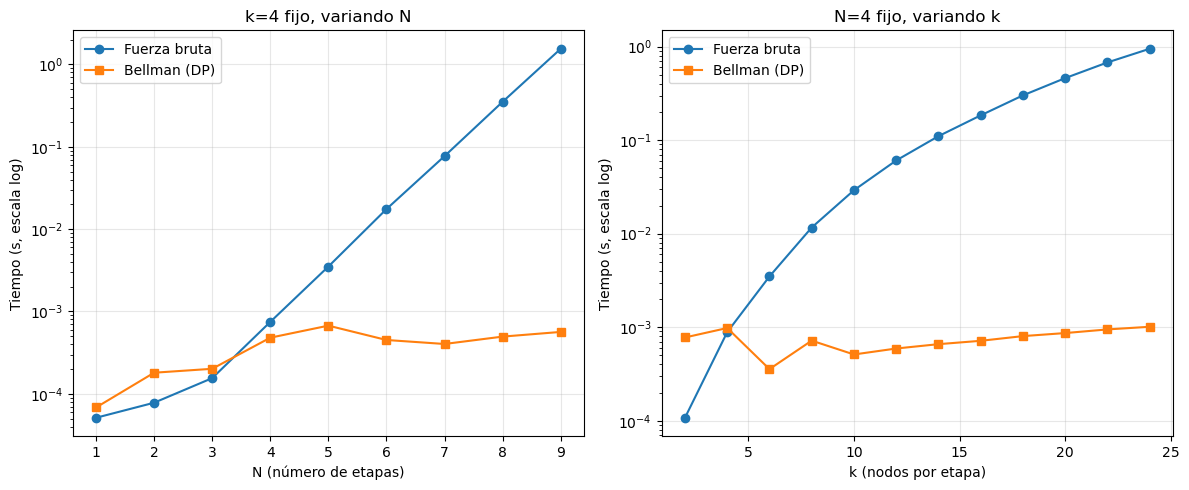

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfica A: variando N (k fijo) ---
N_plot = [r["N"] for r in resultados_A]
tfb_A = [r["t_fb"] for r in resultados_A]
tdp_A = [r["t_dp"] for r in resultados_A]

axes[0].semilogy(N_plot, tfb_A, "o-", label="Fuerza bruta")
axes[0].semilogy(N_plot, tdp_A, "s-", label="Bellman (DP)")
axes[0].set_xlabel("N (número de etapas)")
axes[0].set_ylabel("Tiempo (s, escala log)")
axes[0].set_title(f"k={k_vals_fijo[0]} fijo, variando N")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Gráfica B: variando k (N fijo) ---
k_plot = [r["k"] for r in resultados_B]
tfb_B = [r["t_fb"] for r in resultados_B]
tdp_B = [r["t_dp"] for r in resultados_B]

axes[1].semilogy(k_plot, tfb_B, "o-", label="Fuerza bruta")
axes[1].semilogy(k_plot, tdp_B, "s-", label="Bellman (DP)")
axes[1].set_xlabel("k (nodos por etapa)")
axes[1].set_ylabel("Tiempo (s, escala log)")
axes[1].set_title(f"N={N_vals_fijo[0]} fijo, variando k")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Los resultados confirman lo mencionado anteriormente con respecto a la teórica. El tiempo de fuerza bruta crece exponencialmente con N (aumenta ~4-5x cada vez que N crece en 1, consistente con k=4) y polinomialmente con k (consistente con el exponente N=4 fijo), mientras que el tiempo de Bellman crece de forma mucho más suave en ambos casos, acorde 
con su complejidad O(N·k²). 

Para N=9, k=4, fuerza bruta tardó cerca de 1400 veces más que Bellman y la brecha sigue creciendo con N, lo cual confirman que la 
programación dinámica es sustancialmente más eficiente para este problema.

### 1.4. Algoritmo de Dijkstra

Dijkstra es un algoritmo greedy (voraz) que encuentra la ruta más corta desde un origen hacia todos los nodos de un grafo con pesos no negativos, usando una cola de 
prioridad para procesar en cada paso el nodo no visitado de menor distancia tentativa. Comparte el principio de optimalidad de Bellman, es decir, que la ruta óptima se construye a partir de rutas óptimas a subproblemas, sin reconsiderar decisiones ya tomadas, pero difiere en que Dijkstra está pensado para grafos generales sin estructura conocida, por lo que necesita decidir dinámicamente el orden de procesamiento (de ahí la cola de prioridad y su complejidad O((V+E)log V)). Nuestro algoritmo, en cambio, aprovecha que el 
grafo es por etapas, lo que permite recorrerlo hacia atrás en un orden fijo sin necesidad de cola de prioridad, logrando una complejidad más baja, O(N·k²).